In [8]:
import pandas as pd
import numpy as np
import matplotlib as mpl


In [3]:
data = pd.read_csv('../eurusd1H.csv', parse_dates=['time'], index_col='time')
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 12431 entries, 2024-01-01 22:00:00 to 2025-12-30 22:00:00
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   c       12431 non-null  float64
dtypes: float64(1)
memory usage: 194.2 KB


In [5]:
rollup = 20
k = 2
data['mb'] = data['c'].rolling(rollup).mean()
data['ub'] = data['mb'] + (k * data['c'].rolling(rollup).std())
data['lb'] = data['mb'] - (k * data['c'].rolling(rollup).std())


In [6]:
data.head(30)


,c,mb,ub,lb
time,,,,
2024-01-01 22:00:00,1.10438,NaN,NaN,NaN
2024-01-01 23:00:00,1.10359,NaN,NaN,NaN
2024-01-02 00:00:00,1.10375,NaN,NaN,NaN
2024-01-02 01:00:00,1.10343,NaN,NaN,NaN
2024-01-02 02:00:00,1.10181,NaN,NaN,NaN
2024-01-02 03:00:00,1.10239,NaN,NaN,NaN
2024-01-02 04:00:00,1.10203,NaN,NaN,NaN
2024-01-02 05:00:00,1.10328,NaN,NaN,NaN
2024-01-02 06:00:00,1.10280,NaN,NaN,NaN


<Axes: xlabel='time'>

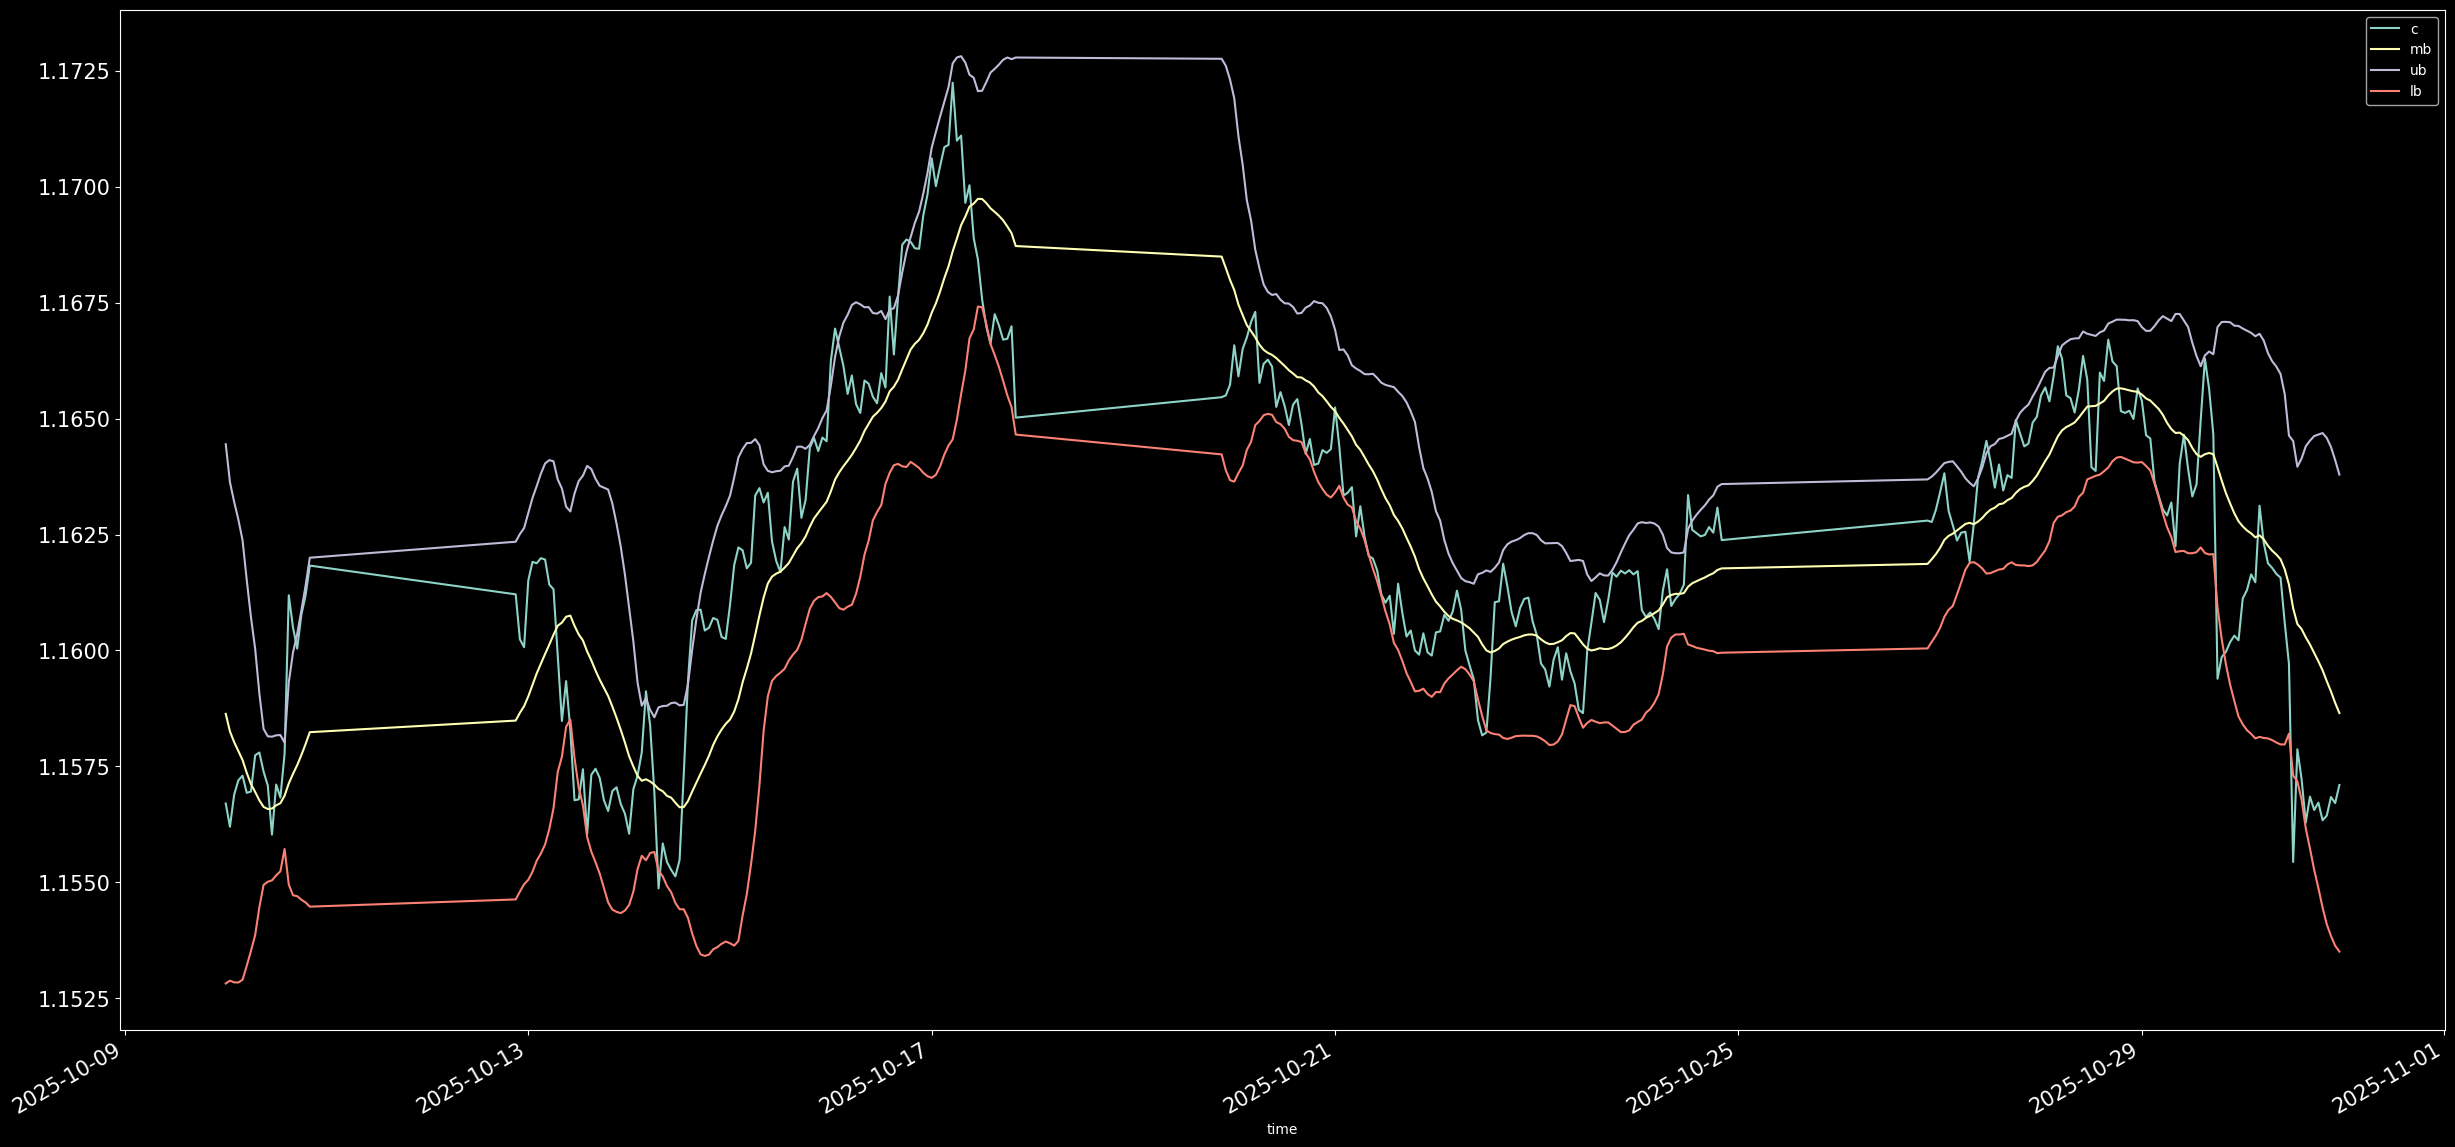

In [18]:
data.loc['2025-10-10':'2025-10-30'].plot(figsize=(30, 15), fontsize=15)

RSI

In [21]:
data['gain'] = np.where((data['c'] > data['c'].shift(1)), data['c']-data['c'].shift(1), 0)
data['loss'] = np.where((data['c'] < data['c'].shift(1)),data['c'].shift(1) - data['c'], 0)


In [47]:
data['avg_gain'] = data['gain'].rolling(14).mean()
data['avg_loss'] = data['loss'].rolling(14).mean()


In [48]:
data['rs'] = data['avg_gain']/data['avg_loss']


In [38]:
data.dropna(inplace=True)
data.info()


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 12399 entries, 2024-01-03 06:00:00 to 2025-12-30 22:00:00
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   c         12399 non-null  float64
 1   gain      12399 non-null  float64
 2   loss      12399 non-null  float64
 3   avg_gain  12399 non-null  float64
 4   avg_loss  12399 non-null  float64
 5   rs        12399 non-null  float64
 6   rsi       12399 non-null  float64
dtypes: float64(7)
memory usage: 774.9 KB


In [44]:
data['rsi'] = 100 - (100/(1+data['rs']))


<Axes: xlabel='time'>

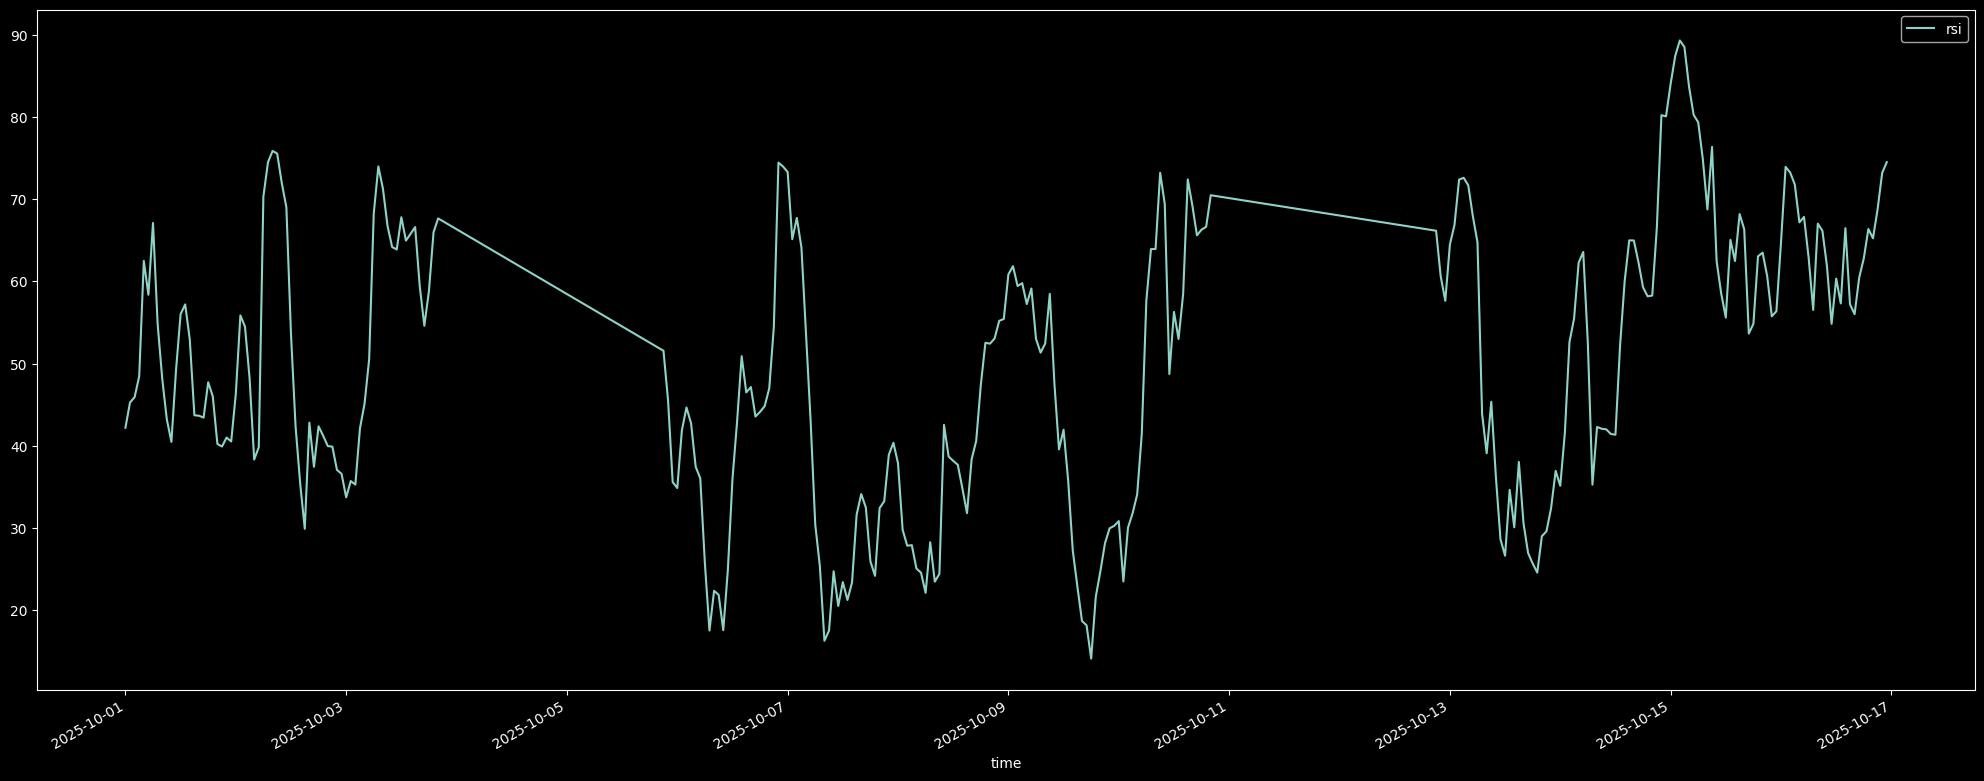

In [50]:
data.loc['2025-10-01':'2025-10-16', ['rsi']].plot(figsize=(25, 10))

macd

In [51]:
fast = 12
slow = 26
signl = 9


In [53]:
a = 2/(fast + 1)
data['ema_fast'] = a * data['c'] + (1 - a) * data['ema_fast'].shift(1)

KeyError: 'ema_fast'